<a href="https://colab.research.google.com/github/ishinidewmini/Image-Processing-Assignment/blob/main/D_ENG_0036_EE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Picture1.jpg to Picture1 (2).jpg


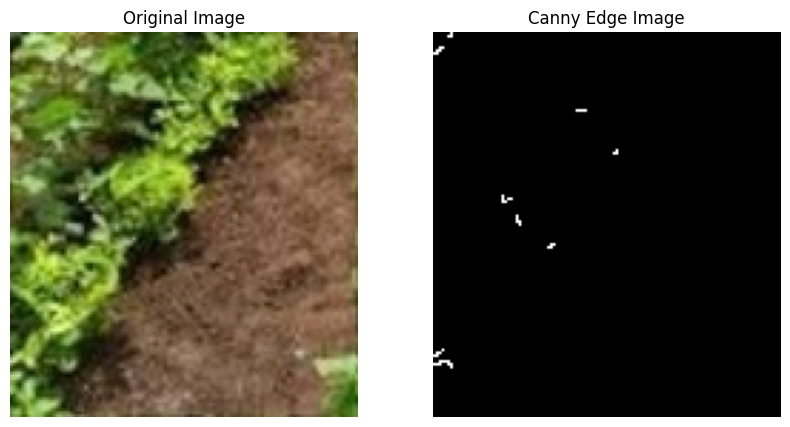

In [2]:
# Step 1: Import required libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Upload image (Fig 1c - cropped image)
from google.colab import files
uploaded = files.upload()

# Get the uploaded file name
image_path = list(uploaded.keys())[0]

# Step 3: Read the image
img = cv.imread(image_path)

# Convert BGR to RGB (for correct display)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert to grayscale (Canny works on grayscale)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 4: Apply Canny Edge Detection
edges = cv.Canny(gray, 550, 690)

# Step 5: Display original and edge images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Image")
plt.axis('off')

plt.show()

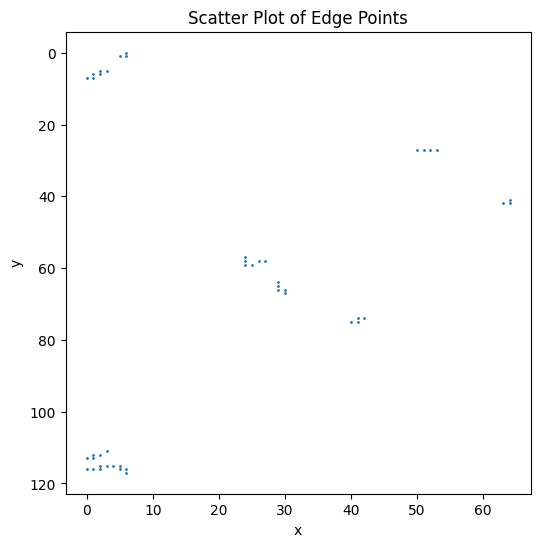

In [3]:
# Step 1: Get coordinates of edge pixels
indices = np.where(edges != 0)

x = indices[1]   # column indices
y = indices[0]   # row indices

# Step 2: Plot scatter graph
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1)   # s=1 for small dots

plt.title("Scatter Plot of Edge Points")
plt.xlabel("x")
plt.ylabel("y")

# Invert y-axis to match image coordinate system
plt.gca().invert_yaxis()

plt.show()

Slope (m): -0.5561511323417759
Intercept (c): 75.61825646556832


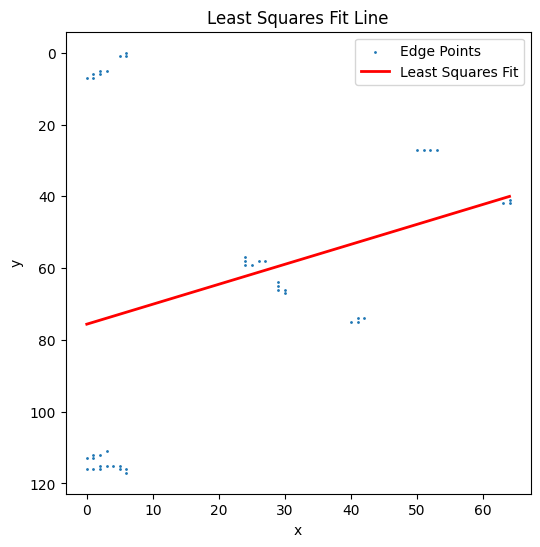

In [4]:
# Step 1: Fit a least-squares line (y = mx + c)
m, c = np.polyfit(x, y, 1)

print("Slope (m):", m)
print("Intercept (c):", c)

# Step 2: Generate fitted line values
x_line = np.linspace(min(x), max(x), 1000)
y_line = m * x_line + c

# Step 3: Plot scatter + fitted line
plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(x, y, s=1, label="Edge Points")

# Best-fit line
plt.plot(x_line, y_line, color='red', linewidth=2, label="Least Squares Fit")

plt.title("Least Squares Fit Line")
plt.xlabel("x")
plt.ylabel("y")

# Match image coordinate system
plt.gca().invert_yaxis()

plt.legend()
plt.show()

In [8]:
# Step 1: Calculate angle from slope (m)
theta_rad = np.arctan(m)   # angle in radians

# Step 2: Convert to degrees
theta_deg = np.degrees(theta_rad)

# Step 3: Display result
print("Estimated Crop Field Angle (radians):", theta_rad)
print("Estimated Crop Field Angle (degrees):", theta_deg)

Estimated Crop Field Angle (radians): -0.5075534998832897
Estimated Crop Field Angle (degrees): -29.08067342040622


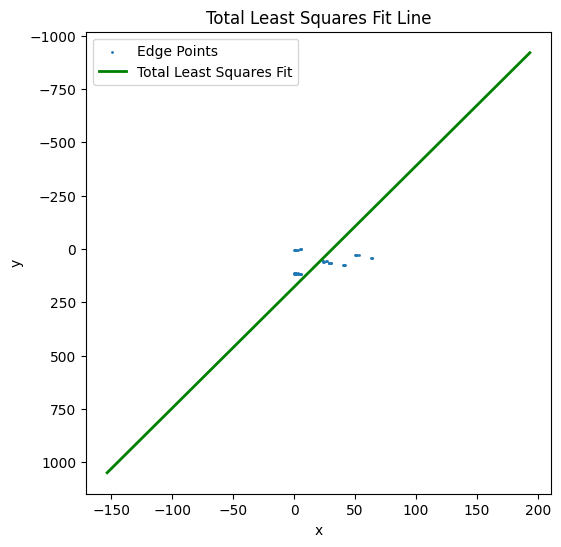

In [9]:
# Step 1: Convert x and y into column vectors
x_mean = np.mean(x)
y_mean = np.mean(y)

# Center the data
X = x - x_mean
Y = y - y_mean

# Stack into a 2D matrix
A = np.vstack((X, Y)).T

# Step 2: Apply SVD
U, S, Vt = np.linalg.svd(A)

# The direction vector of the best-fit line
direction = Vt[0]   # principal component

dx = direction[0]
dy = direction[1]

# Step 3: Generate line points
t = np.linspace(-1000, 1000, 1000)

x_line = x_mean + t * dx
y_line = y_mean + t * dy

# Step 4: Plot scatter + TLS line
plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(x, y, s=1, label="Edge Points")

# TLS fitted line
plt.plot(x_line, y_line, color='green', linewidth=2, label="Total Least Squares Fit")

plt.title("Total Least Squares Fit Line")
plt.xlabel("x")
plt.ylabel("y")

# Match image coordinate system
plt.gca().invert_yaxis()

plt.legend()
plt.show()

In [11]:
# Step 1: Calculate angle using direction vector from TLS
theta_tls_rad = np.arctan2(dy, dx)   # angle in radians

# Step 2: Convert to degrees
theta_tls_deg = np.degrees(theta_tls_rad)

# Step 3: Display result
print("TLS Estimated Angle (radians):", theta_tls_rad)
print("TLS Estimated Angle (degrees):", theta_tls_deg)

TLS Estimated Angle (radians): 1.7451875740798142
TLS Estimated Angle (degrees): 99.99188245344806


RANSAC Slope: -1.39970271464003
RANSAC Intercept: 113.09007406652398


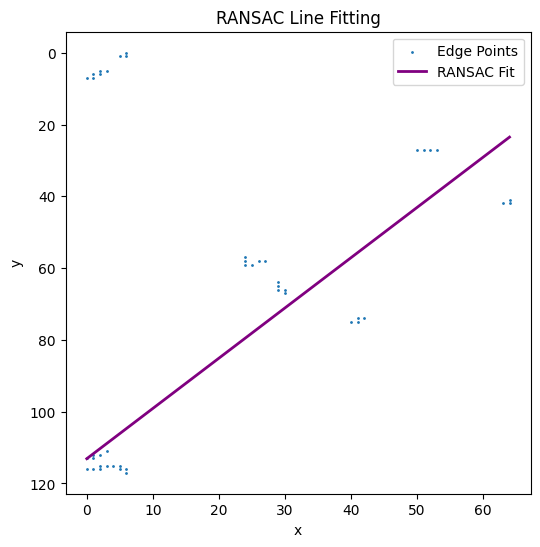

In [12]:
# Step 1: Import required library
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression

# Step 2: Reshape data (required format for sklearn)
X_ransac = x.reshape(-1, 1)   # independent variable
Y_ransac = y                 # dependent variable

# Step 3: Apply RANSAC
ransac = RANSACRegressor(LinearRegression())
ransac.fit(X_ransac, Y_ransac)

# Get slope and intercept
m_ransac = ransac.estimator_.coef_[0]
c_ransac = ransac.estimator_.intercept_

print("RANSAC Slope:", m_ransac)
print("RANSAC Intercept:", c_ransac)

# Step 4: Generate fitted line
x_line = np.linspace(min(x), max(x), 1000)
y_line = m_ransac * x_line + c_ransac

# Step 5: Plot results
plt.figure(figsize=(6,6))

# Plot all points
plt.scatter(x, y, s=1, label="Edge Points")

# Plot RANSAC line
plt.plot(x_line, y_line, color='purple', linewidth=2, label="RANSAC Fit")

plt.title("RANSAC Line Fitting")
plt.xlabel("x")
plt.ylabel("y")

# Match image coordinate system
plt.gca().invert_yaxis()

plt.legend()
plt.show()